In [42]:
from matplotlib import pyplot as plt
import numpy as np
from stable_baselines3.common.monitor import load_results
import os
import pandas as pd
import numpy as np
from typing import cast
from psai.game.objects import State, Cell, PlayerStats
from psai.visuals.skia_render import SkiaRenderer
from tqdm import tqdm

## Load files

In [47]:
most_recent = True
if most_recent:
    logs_folder = os.path.join("../logs/", sorted([x for x in os.listdir("../logs/") if x.startswith("run_")])[-1])
else:
    logs_folder = "../logs/run_2025-10-03_20-10-39/"
all_results_dfs = []
for subfolder in os.listdir(logs_folder):
    i = int(subfolder.split('_')[-1])
    results_df = load_results(os.path.join(logs_folder, subfolder))
    results_df['training_round'] = i
    all_results_dfs.append(results_df)
full_results_dfs = pd.concat(all_results_dfs)
episode_rewards = cast(np.ndarray, full_results_dfs['r'].values)

## Plot reward

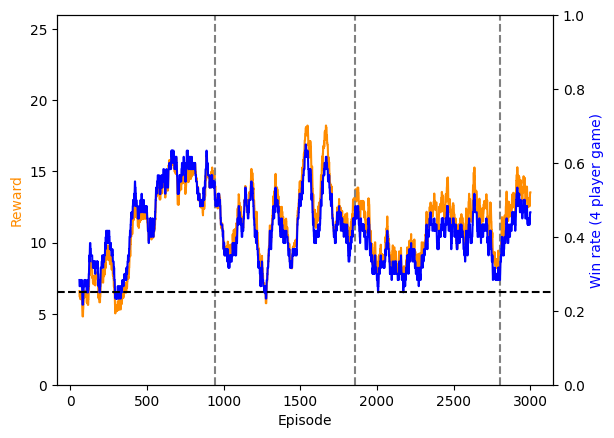

In [51]:
window_size = 60

reward_binary = (episode_rewards > 0).astype(int)
rolling_mean = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
rolling_binary_mean = np.convolve(reward_binary, np.ones(window_size)/window_size, mode='valid')

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

xvals = np.arange(len(rolling_mean)) + window_size - 1

ax1.plot(xvals, rolling_mean, label='Rolling Mean (window=10)', color='darkorange')
ax2.plot(xvals, rolling_binary_mean, label='Rolling Binary Mean (window=10)', color='blue')
# plt.title('Training episode_rewards over Episodes')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward', color='darkorange')
ax2.set_ylabel('Win rate (4 player game)', color='blue')
ax1.set_ylim(0, 26)
ax2.set_ylim(0, 1)

new_model_points = full_results_dfs['training_round'].value_counts().sort_index().cumsum().values[:-1]
ax1.vlines(new_model_points, ymin=0, ymax=26, colors='gray', linestyles='dashed', label='New Model')

plt.gca().axhline(y=0.25, color='k', linestyle='--')
plt.show()


In [7]:
states = [
State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=None, size=None, used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=None, size=None, used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=None, size=None, used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=None, size=None, used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=None, size=None, used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=True), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=True), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=None, size=None, used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=True), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=True), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=None, size=None, used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=True), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=True), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=True), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=None, size=None, used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=True), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=True), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=True), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=True), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=None, size=None, used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=True), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=True), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=6, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=None, size=None, used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=True), Cell(loc=(0, 7), owner=1, size='small', used=True), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=True), Cell(loc=(0, 7), owner=1, size='small', used=True), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=None, size=None, used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=1, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=True), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=True), Cell(loc=(0, 7), owner=1, size='small', used=True), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=True), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=True), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=True), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='small', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='small', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=1, large_ready=1)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=None, size=None, used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=1, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=True), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=True), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='small', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=True), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=True), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=0, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=3, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='seed', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='seed', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='small', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=3, score=0, seed_stash=4, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='seed', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=0, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=5, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=1, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=None, size=None, used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=1, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=True), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='seed', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=1, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=True), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=2, medium_ready=0, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=8, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=2, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=1, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=4, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=0, seed_stash=4, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='small', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=4, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=None, size=None, used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=True), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=True), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=None, size=None, used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=True), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=True), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=1, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=True), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=True), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=True), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=True), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=None, size=None, used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=True), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=True), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=None, size=None, used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=True), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=True), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='small', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=True), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=True), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=None, size=None, used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=1, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=True), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=True), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='seed', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=True), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='seed', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=3, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=2, small_ready=1, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=1, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=5, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='seed', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='small', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='seed', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='medium', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=0, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=6, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=3, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=None, size=None, used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=1, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=True), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=True), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='small', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='medium', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=3, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=2, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=1, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='seed', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=6, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=1, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=None, size=None, used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=1, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=True), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=0, size='seed', used=True), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=3, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=True), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=None, size=None, used=False), Cell(loc=(2, 4), owner=0, size='seed', used=True), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=1, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=True), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=True), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=True), Cell(loc=(2, 4), owner=0, size='seed', used=True), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='medium', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=2, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=None, size=None, used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=True), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=True), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=2, score=0, seed_stash=1, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=3, size='large', used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=0, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=0),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=True), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=1, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=0, seed_stash=2, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=None, size=None, used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=1, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=True), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=2, size='seed', used=True), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=3, size='large', used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=4, score=14, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=1, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=1),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=True), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=3, hour=3, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=5, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='seed', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=10, score=0, seed_stash=2, seed_ready=0, small_stash=0, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=9, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='small', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=6, score=0, seed_stash=3, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='medium', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='medium', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=3, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=1, medium_ready=0, large_stash=0, large_ready=2), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=4, hour=4, player_stats={0: PlayerStats(light=11, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=1, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=0, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=1, size='large', used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=4, score=0, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=2),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=True), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=2, n_score_cards_taken=3),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='seed', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=1, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=3),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=2, size='large', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=5, score=0, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=3),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=True), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=1, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=2, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='seed', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=1, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=3, seed_ready=0, small_stash=0, small_ready=3, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=5, hour=5, player_stats={0: PlayerStats(light=18, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=1, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=0, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=2, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=23, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='small', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=19, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=0, medium_ready=1, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='medium', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=17, score=0, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=0, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='medium', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='seed', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=14, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=1, medium_stash=0, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='medium', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=13, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=0, medium_stash=0, medium_ready=0, large_stash=2, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='medium', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=9, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=0, medium_stash=0, medium_ready=0, large_stash=1, large_ready=1), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=6, score=0, seed_stash=1, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=None, size=None, used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=1, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=True), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=True), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=8, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=0), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=3, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=6, score=11, seed_stash=1, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=None, size=None, used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=4, score=11, seed_stash=0, seed_ready=1, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=True), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=True), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=4, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=2, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=True), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=True), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=1, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=0, hour=0, player_stats={0: PlayerStats(light=4, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=0, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=1, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=1, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=0), 1: PlayerStats(light=2, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=2, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=2, score=12, seed_stash=3, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=1, score=12, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=1, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='small', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=1, score=12, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=3, score=11, seed_stash=0, seed_ready=0, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='medium', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=1, score=12, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=1, score=11, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=2, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='medium', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=1, hour=1, player_stats={0: PlayerStats(light=0, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=1, score=12, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=1, score=11, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=3, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=3, day=3, n_score_cards_taken=4),


State(board_state=[Cell(loc=(0, 0), owner=None, size=None, used=False), Cell(loc=(0, 1), owner=None, size=None, used=False), Cell(loc=(0, 2), owner=2, size='medium', used=False), Cell(loc=(0, 3), owner=3, size='small', used=False), Cell(loc=(0, 4), owner=1, size='medium', used=False), Cell(loc=(0, 5), owner=1, size='large', used=False), Cell(loc=(0, 6), owner=1, size='small', used=False), Cell(loc=(0, 7), owner=None, size=None, used=False), Cell(loc=(0, 8), owner=0, size='large', used=False), Cell(loc=(0, 9), owner=2, size='seed', used=False), Cell(loc=(0, 10), owner=2, size='medium', used=False), Cell(loc=(0, 11), owner=None, size=None, used=False), Cell(loc=(0, 12), owner=0, size='small', used=False), Cell(loc=(0, 13), owner=2, size='seed', used=False), Cell(loc=(0, 14), owner=0, size='medium', used=False), Cell(loc=(0, 15), owner=2, size='small', used=False), Cell(loc=(0, 16), owner=0, size='seed', used=False), Cell(loc=(0, 17), owner=None, size=None, used=False), Cell(loc=(1, 0), owner=3, size='small', used=False), Cell(loc=(1, 1), owner=0, size='seed', used=False), Cell(loc=(1, 2), owner=2, size='seed', used=False), Cell(loc=(1, 3), owner=1, size='seed', used=False), Cell(loc=(1, 4), owner=0, size='seed', used=False), Cell(loc=(1, 5), owner=2, size='small', used=False), Cell(loc=(1, 6), owner=0, size='small', used=False), Cell(loc=(1, 7), owner=0, size='small', used=False), Cell(loc=(1, 8), owner=1, size='small', used=False), Cell(loc=(1, 9), owner=None, size=None, used=False), Cell(loc=(1, 10), owner=2, size='seed', used=False), Cell(loc=(1, 11), owner=None, size=None, used=False), Cell(loc=(2, 0), owner=0, size='medium', used=False), Cell(loc=(2, 1), owner=None, size=None, used=False), Cell(loc=(2, 2), owner=1, size='small', used=False), Cell(loc=(2, 3), owner=0, size='small', used=False), Cell(loc=(2, 4), owner=0, size='seed', used=False), Cell(loc=(2, 5), owner=None, size=None, used=False), Cell(loc=(3, 0), owner=None, size=None, used=False)], sun_pos=2, hour=2, player_stats={0: PlayerStats(light=5, score=0, seed_stash=0, seed_ready=0, small_stash=0, small_ready=0, medium_stash=1, medium_ready=0, large_stash=0, large_ready=1), 1: PlayerStats(light=8, score=12, seed_stash=2, seed_ready=1, small_stash=1, small_ready=0, medium_stash=1, medium_ready=1, large_stash=0, large_ready=1), 2: PlayerStats(light=4, score=11, seed_stash=0, seed_ready=0, small_stash=2, small_ready=0, medium_stash=1, medium_ready=0, large_stash=1, large_ready=1), 3: PlayerStats(light=5, score=27, seed_stash=4, seed_ready=0, small_stash=0, small_ready=2, medium_stash=3, medium_ready=0, large_stash=2, large_ready=0)}, active_player=0, day=3, n_score_cards_taken=4),
]


## Render animation

In [8]:
renderer = SkiaRenderer(width=1200, height=800)

In [9]:
images = []
for i, st in tqdm(enumerate(states), total=len(states)):
    img = renderer.render_state(st, save_path=None, return_image=True)
    images.append(img)

100%|██████████| 200/200 [00:01<00:00, 168.97it/s]


In [11]:
renderer.save_animation_from_images(images, "gameplay8.gif", fps=8)